## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



## Loading Dataset

In [2]:
dataset = pd.read_csv('DigitalAd_dataset.csv')

In [3]:
print("Dataset Shape:", dataset.shape)

print(dataset.head())


Dataset Shape: (400, 3)
   Age  Salary  Status
0   18   82000       0
1   29   80000       0
2   47   25000       1
3   45   26000       1
4   46   28000       1


## Independent & Dependent Variables


In [4]:
X = dataset.iloc[:, :-1].values 

# values of all columns except last column in the dataset
# That is , Age & Salary

In [5]:
y = dataset.iloc[:, -1].values 

# values of last column only from the dataset
# That is , Status (0 or 1)

## Data Preprocessing

In [6]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler


## Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.25, random_state = 35, stratify = y
)


## Feature Scaling


In [8]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


## Logistic Regression with Hyperparameter Tuning


In [9]:
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import GridSearchCV



In [10]:
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid = GridSearchCV(LogisticRegression(random_state = 55), param_grid, cv = 5, scoring = 'accuracy')
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}


## Predictions


In [11]:
y_pred = best_model.predict(X_test)


## Evaluation

In [12]:
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, classification_report, roc_curve
)


In [13]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))

print("Recall:", recall_score(y_test, y_pred))

print("F1 Score:", f1_score(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.84
Precision: 0.7941176470588235
Recall: 0.75
F1 Score: 0.7714285714285715
ROC-AUC: 0.8203125

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.89      0.88        64
           1       0.79      0.75      0.77        36

    accuracy                           0.84       100
   macro avg       0.83      0.82      0.82       100
weighted avg       0.84      0.84      0.84       100



##  Confusion Matrix Heatmap


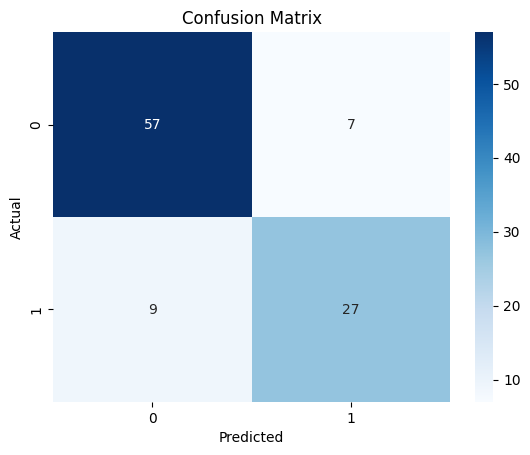

In [14]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


## ROC Curve


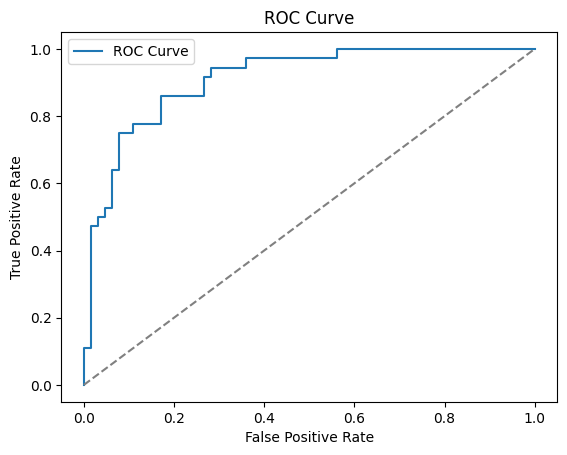

In [15]:
fpr, tpr, thresholds = roc_curve(y_test, best_model.predict_proba(X_test)[:,1])

plt.plot(fpr, tpr, label="ROC Curve")

plt.plot([0,1],[0,1],'--',color='gray')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()


In [16]:
odds_ratios = np.exp(best_model.coef_[0])
for feature, coef, odds in zip(['Age','Salary'], best_model.coef_[0], odds_ratios):
    print(f"{feature}: Coefficient={coef:.4f}, Odds Ratio={odds:.4f}")


Age: Coefficient=2.3708, Odds Ratio=10.7055
Salary: Coefficient=1.2816, Odds Ratio=3.6025


## Example Prediction 

In [17]:
age = 35
salary = 50000
new_customer = sc.transform([[age, salary]])
prediction = best_model.predict(new_customer)[0]
print(f"Prediction for Age={age}, Salary={salary}: {'Will Buy' if prediction==1 else 'Won’t Buy'}")


Prediction for Age=35, Salary=50000: Won’t Buy


## User Input Prediction


In [25]:
age = int(input("Please Enter Your Age: "))

salary = int(input("Please Enter Your Salary: "))

new_customer = sc.transform([[age, salary]])

prediction = best_model.predict(new_customer)[0]

# Display result

if prediction == 1:
    print(" SUCCESS!!!!! Customer will Buy The Products ")
else:
    print("Oops!!!! Customer will NOT Buy The Products")






Please Enter Your Age:  30
Please Enter Your Salary:  25000


Oops!!!! Customer will NOT Buy The Products


In [24]:
proba = best_model.predict_proba(new_customer)[0]
print(f"Probability of No Buy (0): {proba[0]:.2f}")
print(f"Probability of Buy (1): {proba[1]:.2f}")

Probability of No Buy (0): 0.61
Probability of Buy (1): 0.39
